In [ ]:
# импорт необходимых библиотек работы с данными
import pandas as pd
import matplotlib.pyplot as plt


Вариант 12

### **Чтение данных из файла

Прописываем путь к директории, лежат файлы

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# DIR PATH to DATA
dir_path = "/content/drive/My Drive/"

Mounted at /content/drive


Прописываем пути к файлам данным

In [ ]:
csv_file_path_1 = dir_path + 'data_sf.csv'
csv_file_path_1

'/content/drive/My Drive/data_sf.csv'

In [ ]:
# Чтение данных из файла data_sf.csv
data = pd.read_csv(csv_file_path_1)
print(data.shape)
data.head()

(12897, 42)


,Unnamed: 0,Name,Age,Nationality,Club,Value,Wage,Position,Crossing,Finishing,...,Penalties,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes
0,0,L. Messi,31,Argentina,FC Barcelona,110500000,565000,RF,84,95,...,75,96,33,28,26,6,11,15,14,8
1,1,Cristiano Ronaldo,33,Portugal,Juventus,77000000,405000,ST,84,94,...,85,95,28,31,23,7,11,15,14,11
2,2,Neymar Jr,26,Brazil,Paris Saint-Germain,118500000,290000,LW,79,87,...,81,94,27,24,33,9,9,15,15,11
3,3,De Gea,27,Spain,Manchester United,72000000,260000,GK,17,13,...,40,68,15,21,13,90,85,87,88,94
4,4,K. De Bruyne,27,Belgium,Manchester City,102000000,355000,RCM,93,82,...,79,88,68,58,51,15,13,5,10,13


Есть два основных способа сделать выборку: iloc[] по номеру или номерам строки и loc[] по условию

In [ ]:
#У какого игрока самые худшие залпы
data.loc[(data['Volleys']).min()]

,4
Unnamed: 0,4
Name,K. De Bruyne
Age,27
Nationality,Belgium
Club,Manchester City
Value,102000000
Wage,355000
Position,RCM
Crossing,93
Finishing,82


In [ ]:
#Какова максимальная разница в ловкости
data['Agility'].max() - data['Agility'].min()


81

<Axes: ylabel='Frequency'>

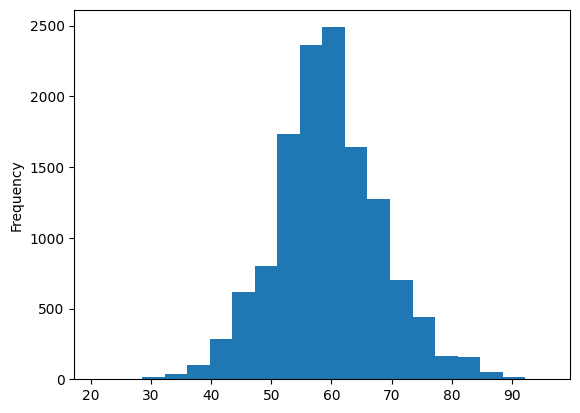

In [ ]:
#Построить гистограмму по реакции
data['Reactions'].plot(kind='hist', bins = 20)




In [ ]:
#Игрок или игроки, которые ближе всего к среднему значению по точности подачи
data.loc[(data['HeadingAccuracy'] == round(data['HeadingAccuracy'].mean()))]

,Unnamed: 0,Name,Age,Nationality,Club,Value,Wage,Position,Crossing,Finishing,...,Penalties,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes
65,65,Douglas Costa,27,Brazil,Juventus,46500000,175000,LM,84,67,...,77,84,45,38,34,13,15,9,12,5
79,79,Marco Asensio,22,Spain,Real Madrid,54000000,215000,RW,82,82,...,62,83,40,42,39,13,9,6,12,10
130,130,I. Gündoğan,27,Germany,Manchester City,32000000,175000,CM,74,73,...,76,87,73,68,64,11,14,5,5,13
162,162,Suso,24,Spain,Milan,33000000,115000,RW,84,70,...,72,76,50,23,18,15,15,9,8,9
164,164,Lucas Moura,25,Brazil,Tottenham Hotspur,31000000,115000,RM,75,78,...,74,80,31,43,51,9,10,14,7,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12700,12929,A. Ammitzbøll,19,Denmark,Aarhus GF,70000,1000,ST,37,50,...,55,43,23,14,18,12,10,10,13,13
12720,12949,Chen Ji,21,China PR,Guizhou Hengfeng FC,50000,2000,LM,41,28,...,42,38,46,48,51,15,8,10,13,7
12748,12977,C. Mesa,20,Colombia,América de Cali,60000,1000,CB,26,17,...,39,39,50,50,52,6,13,7,10,6
12750,12979,L. Valeau,19,Italy,Ascoli,60000,3000,CM,50,30,...,40,42,41,54,55,8,11,13,14,14


Text(0, 0.5, 'ценность')

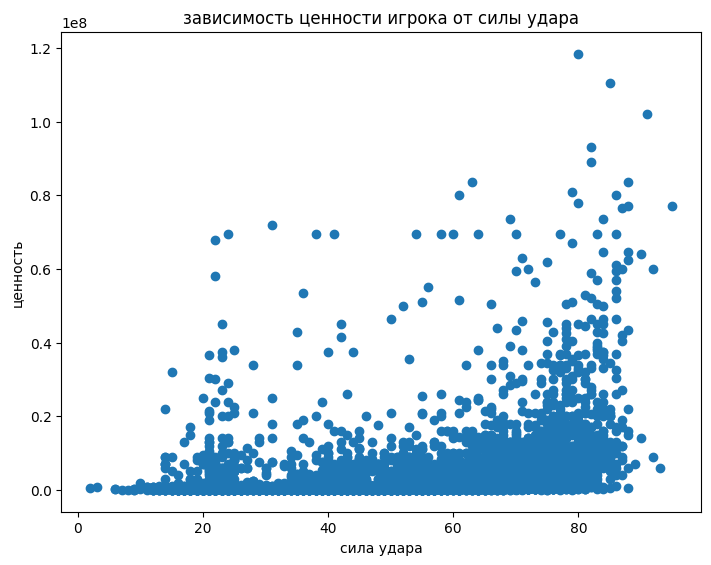

In [ ]:
#Построить зависимость ценности игрока от силы удара
fig = plt.figure()
axes = fig.add_axes([0, 0, 1, 1])
axes.scatter(x = data['ShotPower'], y = data['Value'], marker = 'o')
axes.set_title('зависимость ценности игрока от силы удара')
axes.set_xlabel('сила удара')
axes.set_ylabel('ценность')


In [ ]:
#Сколько пенальти у каждого клуба
data.groupby(['Club'])['Penalties'].sum().sort_values(ascending=False)

,Penalties
Club,
Padova,1462
San Martín de San Juan,1456
Curicó Unido,1436
Lincoln City,1434
Liverpool,1399
...,...
GD Chaves,372
OGC Nice,369
Dijon FCO,361


<Axes: xlabel='Position'>

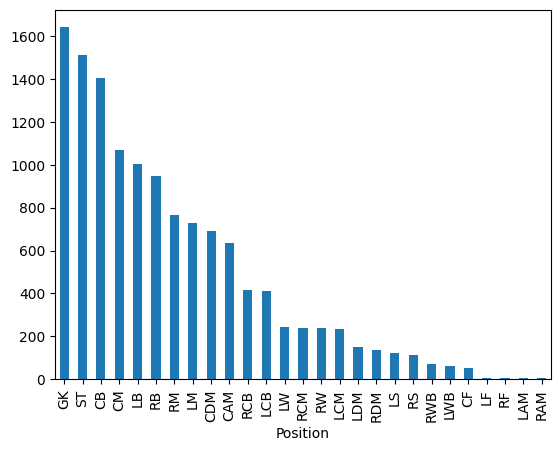

In [ ]:
#По сколько игроков на каждой позиции график
b = data['Position'].value_counts()
b.plot(kind = 'bar')

<Axes: xlabel='Position'>

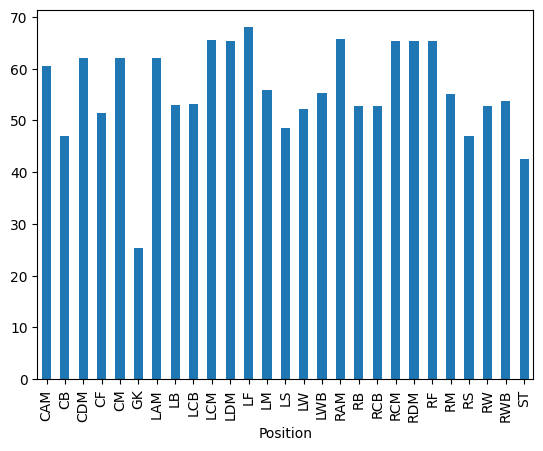

In [ ]:
#Как меняется выносливость в зависимости от позиции график
data.groupby(['Position'])[['Stamina']].mean()
a.plot(kind = 'bar')


In [ ]:
#Средняя сила удара по клубам
data.groupby(['Club'])['ShotPower'].mean()



,ShotPower
Club,
SSV Jahn Regensburg,51.875000
1. FC Heidenheim 1846,55.150000
1. FC Kaiserslautern,54.956522
1. FC Köln,45.500000
1. FC Magdeburg,51.000000
...,...
Zagłębie Sosnowiec,47.080000
Çaykur Rizespor,56.409091
Örebro SK,44.807692


In [ ]:
#Средняя точность подачи по клубам + график
data.groupby(['Club'])['HeadingAccuracy'].mean().sort_values(ascending=False)



,HeadingAccuracy
Club,
Juventus,69.071429
FC Porto,66.333333
Ajax,65.230769
Manchester United,63.900000
RB Leipzig,63.058824
...,...
KAA Gent,41.333333
Los Angeles FC,41.000000
IFK Norrköping,40.928571


<Axes: xlabel='Position'>

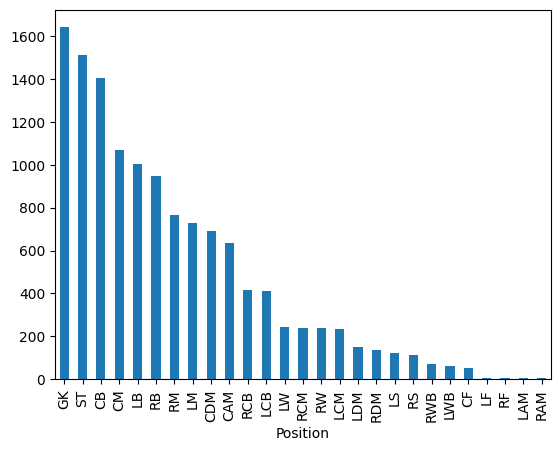

In [ ]:
#Средняя точность подачи по клубам график
b.plot(kind = 'bar')

In [ ]:
#У какого игрока самая высокая зарплата
round(data['Finishing'].max())

95

In [ ]:
#Какова максимальная разница в точности подачи
data['HeadingAccuracy'].max() - data['HeadingAccuracy'].min()

90

<Axes: ylabel='Frequency'>

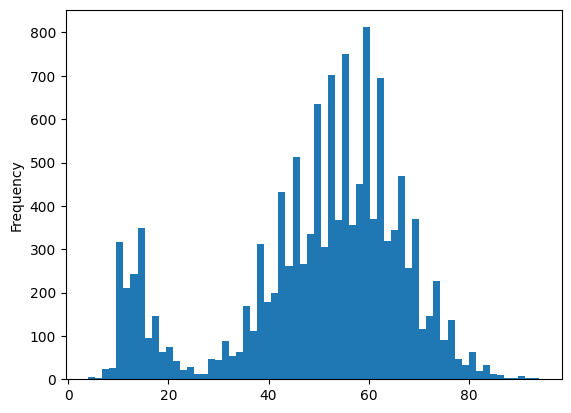

In [ ]:
#Построить гистограмму по точности передачи
data['HeadingAccuracy'].plot(kind = 'hist',bins = 64)



In [ ]:
#Игрок или игроки, которые ближе всего к среднему значению по реакции
data.loc[(data['Reactions'] == round(data['Reactions'].mean()))]


,Unnamed: 0,Name,Age,Nationality,Club,Value,Wage,Position,Crossing,Finishing,...,Penalties,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes
1150,1174,P. Gazzaniga,26,Argentina,Tottenham Hotspur,5000000,46000,GK,21,12,...,41,55,23,20,11,76,73,84,72,76
1633,1700,L. Figueroa,35,Chile,CD Universidad de Concepción,775000,2000,RM,70,54,...,67,62,50,52,56,12,7,12,13,9
1683,1757,J. Gillet,39,Belgium,Standard de Liège,120000,4000,GK,9,12,...,23,59,23,14,12,66,72,69,75,69
1756,1838,Borja Herrera,25,Spain,CF Reus Deportiu,2000000,5000,LB,71,53,...,58,58,64,69,70,7,9,9,10,11
1787,1873,L. Ridgewell,33,England,Portland Timbers,425000,4000,CB,53,49,...,53,56,70,66,66,13,9,12,6,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11608,11831,T. Tanaka,20,Japan,Kashima Antlers,160000,1000,CM,45,31,...,38,52,51,51,49,8,7,8,8,8
11962,12191,Zhao Yingjie,25,China PR,Tianjin TEDA FC,110000,2000,CM,41,53,...,43,38,53,51,47,12,13,7,6,14
12530,12759,Chen Zhechao,23,China PR,Shandong Luneng TaiShan FC,70000,2000,CM,36,35,...,38,45,68,58,52,6,15,10,12,12
12641,12870,C. Royo,17,Germany,SV Darmstadt 98,60000,1000,LB,58,27,...,28,42,45,52,47,11,9,13,10,7


Text(0, 0.5, 'ценность')

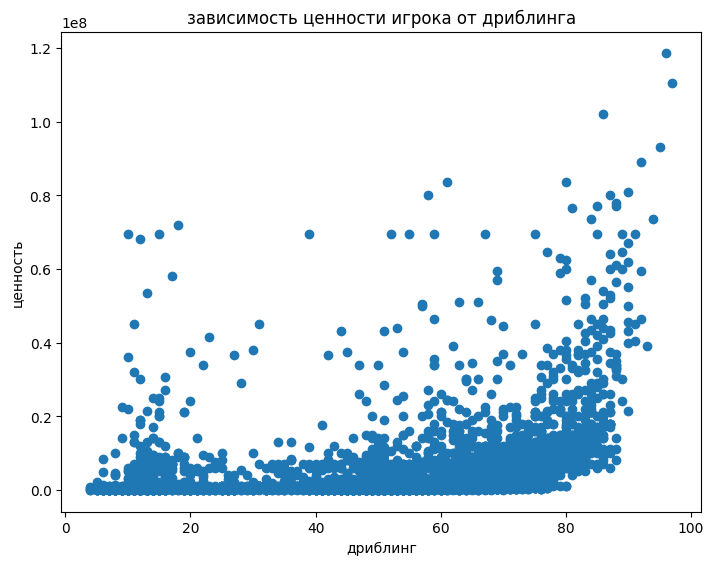

In [ ]:
#Построить зависимость ценности игрока от дриблинга
fig = plt.figure()
axes = fig.add_axes([0, 0, 1, 1])
axes.scatter(x = data['Dribbling'], y = data['Value'], marker = 'o')
axes.set_title('зависимость ценности игрока от дриблинга')
axes.set_xlabel('дриблинг')
axes.set_ylabel('ценность')



In [ ]:
#Сколько игроков каждой национальности
data['Nationality'].value_counts()

,count
Nationality,
England,1368
Germany,919
Spain,671
France,614
Argentina,574
...,...
Malta,1
South Sudan,1
Philippines,1


<Axes: xlabel='Nationality'>

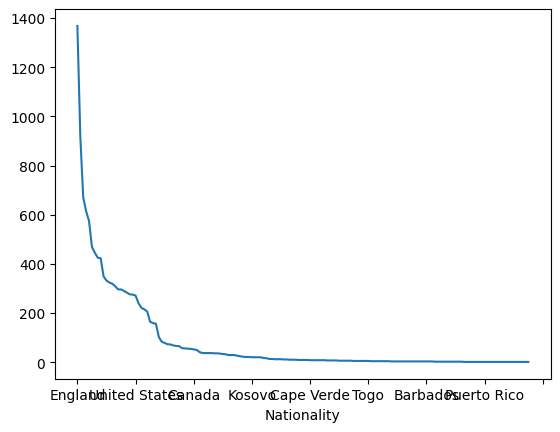

In [ ]:
#Сколько игроков каждой национальности график
dd = data['Nationality'].value_counts()
dd.plot()

<Axes: xlabel='Position'>

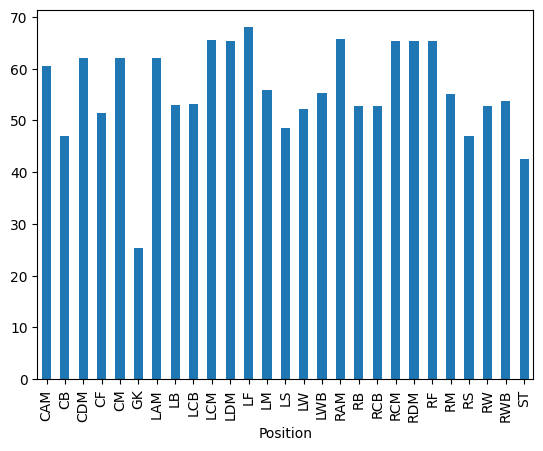

In [ ]:
#Как меняется дальняя передача в зависимости от позиции график
data.groupby(['Position'])[['LongPassing']].mean()
a.plot(kind = 'bar')


In [ ]:
#Средняя точность подачи по клубам
data.groupby(['Club'])['HeadingAccuracy'].mean()


,HeadingAccuracy
Club,
SSV Jahn Regensburg,53.458333
1. FC Heidenheim 1846,47.750000
1. FC Kaiserslautern,49.260870
1. FC Köln,43.400000
1. FC Magdeburg,49.714286
...,...
Zagłębie Sosnowiec,46.080000
Çaykur Rizespor,51.681818
Örebro SK,44.192308


In [ ]:
#Средняя сила удара по клубам + график
data.groupby(['Club'])['ShotPower'].mean()




,ShotPower
Club,
SSV Jahn Regensburg,51.875000
1. FC Heidenheim 1846,55.150000
1. FC Kaiserslautern,54.956522
1. FC Köln,45.500000
1. FC Magdeburg,51.000000
...,...
Zagłębie Sosnowiec,47.080000
Çaykur Rizespor,56.409091
Örebro SK,44.807692


<Axes: xlabel='Nationality'>

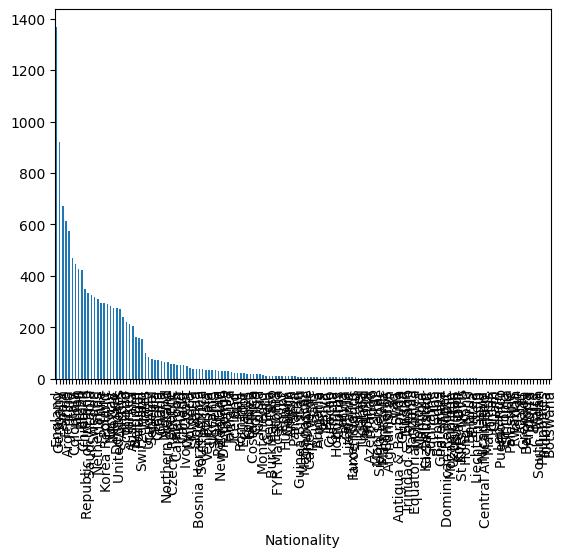

In [ ]:
#Средняя сила удара по клубам
data.groupby(['Club'])['ShotPower'].mean()
b.plot(kind = 'bar')

